# Recipe for identifying and tracking Atmospheric Rivers using wxlib

#### This recipe is relatively untested. The results should be used with caution and scrutinised before being used in any formal analysis 

Written by: Michael Barnes (ARC CoE for 21st Century Weather) | michael.barnes@monash.edu 

In [8]:
import sys
import os
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

Point path to wxlib and import relavent modules

In [9]:
sys.path.append('/g/data/gb02/mb0427/wxlib/functions/')
from nci_utilities import get_GADI_ERA5_filename
from grid import grid_from_xarray
from detect_rivers import detect_rivers

Set the path and date

In [3]:
indt=datetime(2022,3,1)
outpath='/g/data/gb02/mb0427/wxlib/recipes/'

Load the ERA5 vertically integrated water vapour data

In [4]:
fn=xr.open_dataset(get_GADI_ERA5_filename('viwve',indt,level_type='single-levels'))
viwve=fn.resample(time='6h').nearest()['p71.162']
fn=xr.open_dataset(get_GADI_ERA5_filename('viwvn',indt,level_type='single-levels'))
viwvn=fn.resample(time='6h').nearest()['p72.162']
grid=grid_from_xarray(viwve)

Run the "detect river" function

In [24]:
AR_obj,AR_df=detect_rivers(viwve.values,viwvn.values,grid,dT=6,IVTthreshold=250,
                      AR_MinLen=2000, AR_Lat=20, AR_width_lenght_ratio=2,
                      return_data=True,#quiet=False,
                      outpath=None,outfilename=None,
                      min_overlap_perc=25)

Detecting atmospheric rivers ...
   - Calculating IVT ...
   - Detcting potential rivers (thresh_id)...
        connect objects over date line
   - Refining rivers ...
        00:00:17.03
   - Writing out netcdf flag file ...
   - Producing the object characteristics ...
            Loop over 12353 objects
   - Tracking by overlap ...
Completed!
        00:00:33.87


Plot the rivers, centres of mass and tracks

In [25]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, BoundaryNorm
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature, LAND
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

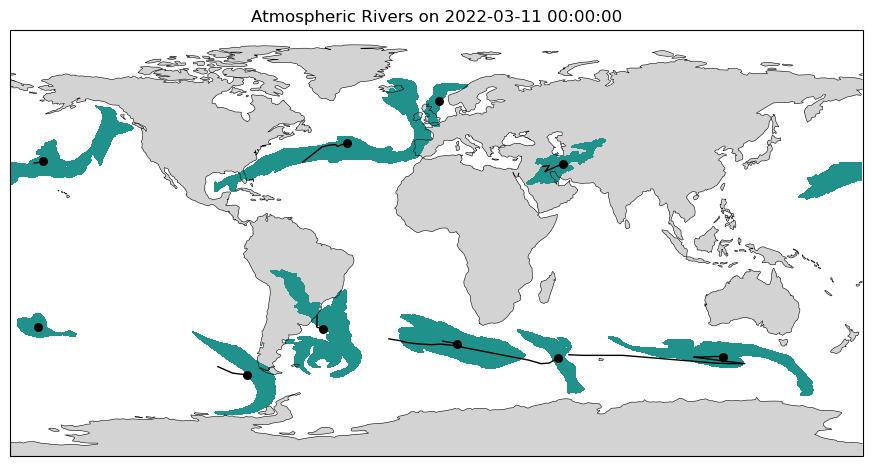

In [26]:
for idt,dt in enumerate(grid['time'][40:41]):
    AR_df_dt=AR_df[AR_df.times==dt]
    AR_df_todt=AR_df[AR_df.times<=dt]
    track_id_dt=AR_df_dt.track_id.to_list()
    com_dt=AR_df_dt.mass_center_coords.to_list()
    xcom_dt=[c[0] for c in com_dt]
    ycom_dt=[c[1] for c in com_dt]
    AR_obj_dt=AR_obj.sel(time=dt)
        
    ################################################################################################################

    figsize=(11,8)
    fig, ax = plt.subplots(1, 1, figsize=figsize, subplot_kw=dict(projection=ccrs.PlateCarree())) 
    
    ax.set_extent([-180,180,-90,90],crs=ccrs.PlateCarree())
    
    ax.add_feature(LAND,facecolor='lightgrey')
    ax.coastlines(linewidths=0.4)
    
    ax.contourf(AR_obj.longitude,AR_obj.latitude,AR_obj_dt,levels=[1,1e10])
    for t in track_id_dt:
        track_to_dt=AR_df_todt[AR_df_todt.track_id==t]
        track_com=track_to_dt.mass_center_coords.to_list()
        xtrack_com=[c[0] for c in track_com]
        ytrack_com=[c[1] for c in track_com]
        ax.plot(xtrack_com,ytrack_com,color='black',linewidth=1)
            
    ax.scatter(xcom_dt,ycom_dt,c='black',s=30)
    ax.set_title('Atmospheric Rivers on '+dt.strftime('%Y-%m-%d %H:%M:%S'))

    plt.show()